In [1]:
pip install pandas numpy scipy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Task 1: Compute Pearson and Spearman Correlations

1. Select all numeric feature pairs in the dataset.
2. Compute the **Pearson** correlation matrix using `pandas` or `scipy`.
3. Compute the **Spearman** correlation matrix for the same pairs.
4. Create a summary table that shows, for each pair, both the Pearson *r* and the Spearman *ρ*, along with their p-values.
5. In a markdown cell, answer:
   - Which pairs show the strongest linear relationships?
   - Are there any pairs where Pearson and Spearman disagree noticeably? What might cause that?


In [8]:
def correlation_summary(df):
    numeric_df = df.select_dtypes(include=[np.number])
    results = []
    cols = numeric_df.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            col1 = cols[i]
            col2 = cols[j]
            temp = numeric_df[[col1, col2]].dropna()

            if len(temp) > 2: 
                pearson_r, pearson_p = pearsonr(temp[col1], temp[col2])
                spearman_rho, spearman_p = spearmanr(temp[col1], temp[col2])

                results.append({
                    'Feature 1': col1,
                    'Feature 2': col2,
                    'Pearson r': pearson_r,
                    'Pearson p-value': pearson_p,
                    'Spearman ρ': spearman_rho,
                    'Spearman p-value': spearman_p
                })

    summary_df = pd.DataFrame(results)
    summary_df = summary_df.sort_values(by='Pearson r', key=abs, ascending=False)
    return summary_df
    
corr_table = correlation_summary(df)
corr_table.head(10)

,Feature 1,Feature 2,Pearson r,Pearson p-value,Spearman ρ,Spearman p-value
14,Pclass,Fare,-0.549500,1.967386e-71,-0.688032,6.194554e-126
18,SibSp,Parch,0.414838,2.241824e-38,0.450014,1.226002e-45
11,Pclass,Age,-0.369226,1.756699e-24,-0.361666,1.736017e-23
6,Survived,Pclass,-0.338481,2.537047e-25,-0.339668,1.687608e-25
15,Age,SibSp,-0.308247,3.509025e-17,-0.182061,9.717194e-07
10,Survived,Fare,0.257307,6.120189e-15,0.323736,3.471228e-23
20,Parch,Fare,0.216225,6.915292e-11,0.410074,1.860780e-37
16,Age,Parch,-0.189119,3.569949e-07,-0.254212,5.408557e-12
19,SibSp,Fare,0.159651,1.671256e-06,0.447113,5.250854e-45
17,Age,Fare,0.096067,1.021628e-02,0.135051,2.958090e-04


The strongest linear relationships (based on Pearson correlation) are:

- Pclass and Fare (r ≈ -0.55): This is the strongest relationship. Higher-class passengers (lower Pclass) tend to pay higher fares.
- SibSp and Parch (r ≈ 0.41): Passengers traveling with siblings/spouses often also travel with parents/children.
- Pclass and Age (r ≈ -0.37): Higher-class passengers tend to be slightly older.
- Survived and Pclass (r ≈ -0.34): Passengers in higher classes had a higher chance of survival.

 Disagreement Between Pearson and Spearman

Yes, there are noticeable differences between Pearson and Spearman correlations for some pairs:

- SibSp and Fare: Pearson ≈ 0.16, Spearman ≈ 0.45  
- Parch and Fare: Pearson ≈ 0.22, Spearman ≈ 0.41  


 Possible Causes of Differences

These differences can be explained by:

- Non-linear relationships: The relationship may not be strictly linear but still monotonic.
- Outliers: The Fare variable is highly skewed and contains extreme values, which affect Pearson more than Spearman.
- Rank-based patterns: Spearman captures relationships based on ranking rather than exact values.


### Task 2: Build a Correlation Heatmap

1. Using `seaborn.heatmap`, create an annotated heatmap of the **Pearson** correlation matrix.
   - Use a diverging colormap (e.g., `coolwarm` or `RdBu_r`) centered at zero.
   - Annotate each cell with the correlation value rounded to two decimal places.
   - Mask the upper triangle so the matrix is easier to read.
2. Create a second heatmap for the **Spearman** matrix using the same layout.
3. In a markdown cell, compare the two heatmaps:
   - Where do they agree?
   - Where do they differ, and what does that tell you about the shape of those relationships?


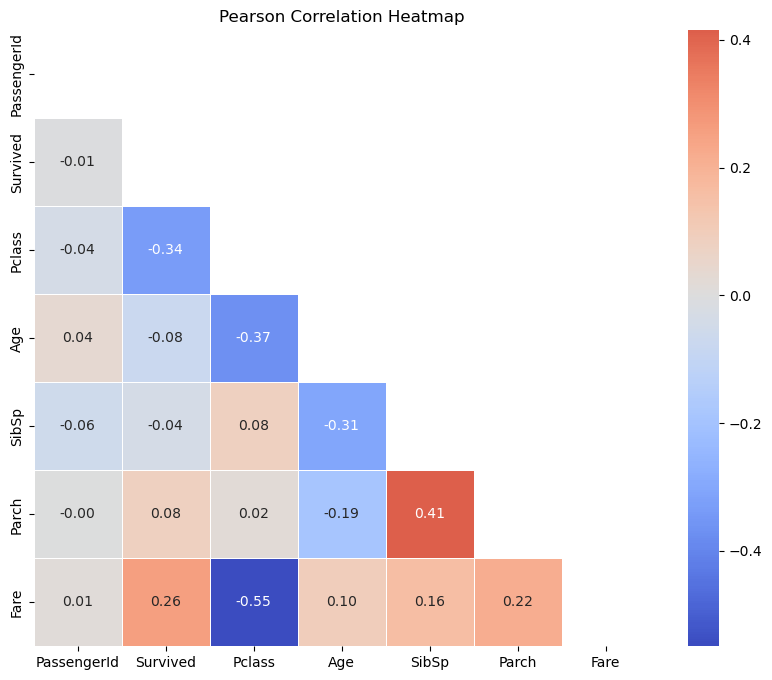

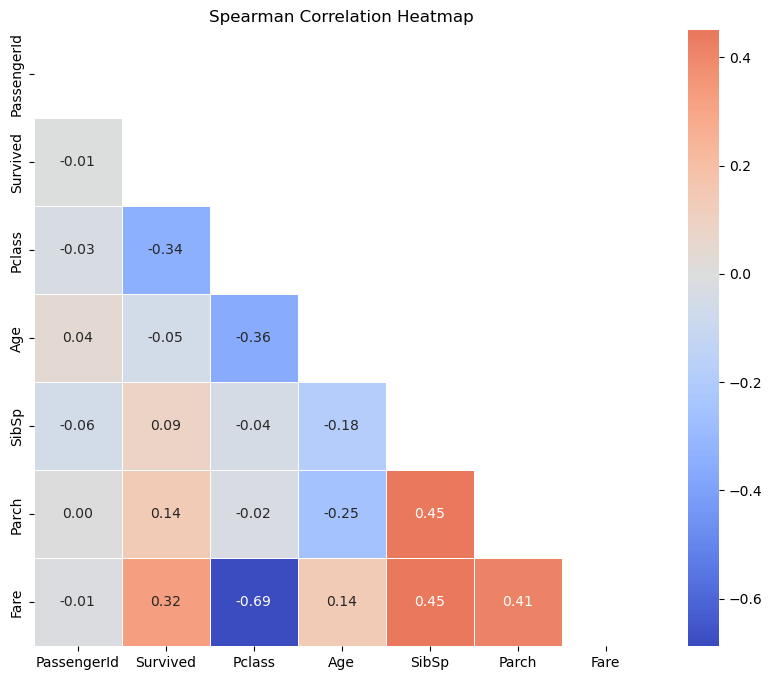

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
pearson_corr = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Pearson Correlation Heatmap")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap")
plt.show()

The Pearson and Spearman heatmaps show strong agreement in several key relationships:

- Pclass and Fare: Strong negative correlation in both (Pearson ≈ -0.55, Spearman ≈ -0.69)
- SibSp and Parch: Moderate positive correlation in both
- Survived and Pclass: Consistent negative relationship
- Age and Pclass: Similar moderate negative correlation

This agreement indicates that these relationships are both linear and monotonic, meaning they follow a clear and consistent trend.


Some feature pairs show noticeable differences:

- SibSp and Fare  
  - Pearson ≈ 0.16 (weak)  
  - Spearman ≈ 0.45 (moderate)

- Parch and Fare  
  - Pearson ≈ 0.22  
  - Spearman ≈ 0.41  

- Survived and Fare  
  - Pearson ≈ 0.26  
  - Spearman ≈ 0.32  

In these cases, Spearman correlations are significantly stronger than Pearson.


These differences suggest that:

- The relationships are not strictly linear
- They are likely monotonic but nonlinear
- The Fare variable is highly skewed and contains outliers

Pearson measures linear relationships and is sensitive to extreme values, while Spearman is based on ranking and captures general trends more effectively.


### Task 3: Scatterplot Analysis of Key Pairs

1. Pick the **three** feature pairs with the highest absolute Pearson correlation.
2. For each pair, produce a scatterplot with:
   - A regression line (use `seaborn.regplot` or `seaborn.lmplot`).
   - Points colored by a categorical grouping variable (e.g., species, sex, or day).
3. In a markdown cell, discuss:
   - Does the regression line capture the actual pattern well?
   - Do subgroups show different slopes or intercepts?


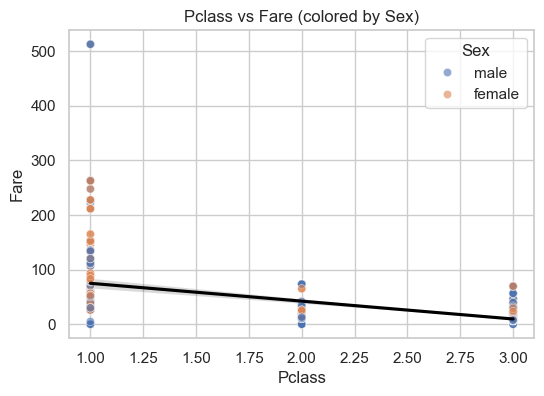

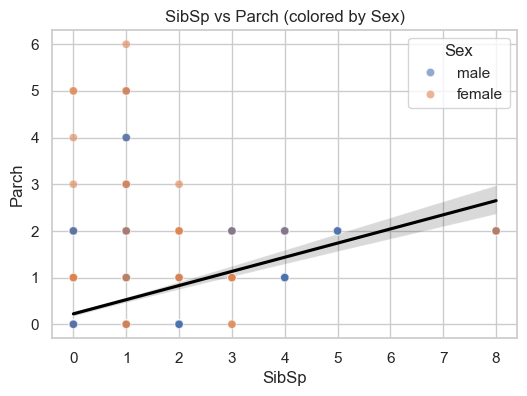

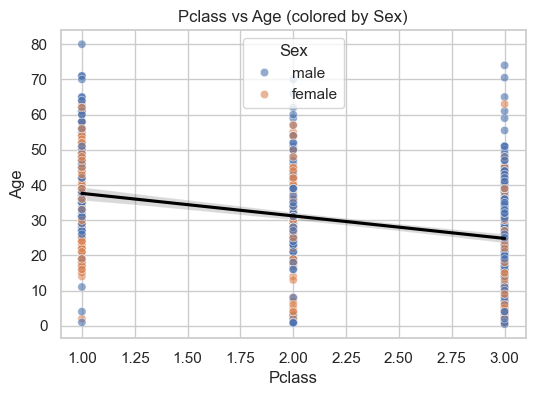

In [10]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.regplot(data=df, x="Pclass", y="Fare", scatter=False, color="black")  # regression line
sns.scatterplot(data=df, x="Pclass", y="Fare", hue="Sex", alpha=0.6)
plt.title("Pclass vs Fare (colored by Sex)")
plt.show()


plt.figure(figsize=(6,4))
sns.regplot(data=df, x="SibSp", y="Parch", scatter=False, color="black")
sns.scatterplot(data=df, x="SibSp", y="Parch", hue="Sex", alpha=0.6)
plt.title("SibSp vs Parch (colored by Sex)")
plt.show()


plt.figure(figsize=(6,4))
sns.regplot(data=df, x="Pclass", y="Age", scatter=False, color="black")
sns.scatterplot(data=df, x="Pclass", y="Age", hue="Sex", alpha=0.6)
plt.title("Pclass vs Age (colored by Sex)")
plt.show()

 Does the regression line capture the actual pattern well?

- Pclass vs Fare:  
  The regression line captures the overall negative trend (higher class → higher fare), but it does not represent the data perfectly.  
  The data is highly skewed with several outliers (very high fares), so the relationship is not strictly linear.

- SibSp vs Parch:  
  The regression line captures the general positive trend reasonably well.  
  However, the data is discrete and clustered at integer values, so the relationship is step-like rather than continuous.

- Pclass vs Age:  
  The regression line shows a weak negative trend, but it does not strongly represent the actual pattern.  
  The data is widely scattered, indicating a weak relationship.

 Do subgroups show different slopes or intercepts?

- Across all three plots, subgroups (based on Sex) mostly overlap.
- There is no strong evidence of different slopes between males and females.
- Some slight differences in spread (especially in Fare) can be observed, but they do not significantly change the overall relationship.
